<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


<Axes: xlabel='fake_or_factual'>

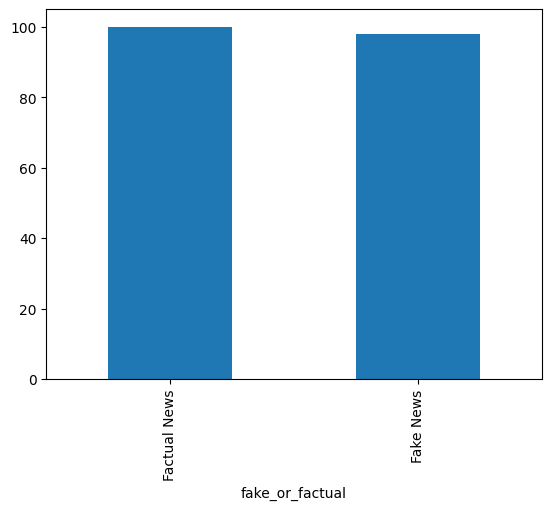

In [18]:
import pandas as pd
data = pd.read_csv('Data/fake_news_data.csv')
data.head()
data.info()
data['fake_or_factual'].value_counts().plot(kind='bar')

In [19]:
data.head(1)

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News


In [26]:
d = data.copy()
#lowercase 
d['text'] = d['text'].apply(lambda s: [word.lower() for word in s.split()])
#stopwords
from nltk.corpus import stopwords
en_words = stopwords.words('english')
d['text'] = d['text'].apply(lambda s: [word for word in s if word not in en_words])
#re
import re
d['text'] = d['text'].apply(lambda s: ' '.join([re.sub(r'[^\s\w]', '', word) for word in s]))
#tokenizer
from nltk import word_tokenize
d['text'] = d['text'].apply(lambda s: word_tokenize(s))

In [21]:
#lemmatization
import nltk
from nltk.stem import WordNetLemmatizer
lm = WordNetLemmatizer()
d['text'] = d['text'].apply(lambda tokens : [lm.lemmatize(token) for token in tokens])

clean_token = sum(d['text'], [])
unigrams = pd.Series(nltk.ngrams(clean_token, 1)).value_counts().reset_index()
unigrams[:5]

# most common bigrams after preprocessing
bigrams = (pd.Series(nltk.ngrams(clean_token, 2)).value_counts()) 
print(bigrams[:10])


(donald, trump)            113
(united, state)             84
(white, house)              74
(president, donald)         47
(hillary, clinton)          39
(new, york)                 34
(washington, reuters)       32
(supreme, court)            30
(image, via)                29
(trump, administration)     26
Name: count, dtype: int64


In [22]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader_sentiment = SentimentIntensityAnalyzer()
d['text'] = d['text'].apply(lambda s : ' '.join([word for word in s]))
d['Sentiment_score'] = d['text'].apply(lambda review : vader_sentiment.polarity_scores(review)['compound'])

bins = [-1, -0.1, 0.1, 1]
names = ['Negatif', 'Neutral', 'Positif']
d['Sentiment_label'] = pd.cut(d['Sentiment_score'], bins, labels=names)


In [23]:
d

,title,text,date,fake_or_factual,Sentiment_score,Sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,two small problem analogy susan jesus muslim j...,"Dec 30, 2015",Fake News,-0.4588,Negatif
1,Elijah Cummings Called Trump Out To His Face ...,buried trump bonkers interview new york time r...,"April 6, 2017",Fake News,-0.7070,Negatif
2,Hillary Clinton Says Half Her Cabinet Will Be...,woman make 50 percent country grossly underrep...,"April 26, 2016",Fake News,0.9775,Positif
3,Russian bombing of U.S.-backed forces being di...,washington reuters u defense secretary jim mat...,"September 18, 2017",Factual News,-0.1531,Negatif
4,Britain says window to restore Northern Irelan...,belfast reuters northern ireland political par...,"September 4, 2017",Factual News,0.9300,Positif
...,...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,well take long look first beastiality marriage...,"Jul 2, 2015",Fake News,0.9698,Positif
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,florida toxic dangerous stand ground gun cultu...,"July 17, 2016",Fake News,-0.9946,Negatif
195,The Los Angeles Times Endorses Hillary Clinto...,politico report almost neckandneck race hillar...,"May 30, 2016",Fake News,0.9938,Positif
196,FBI chief sought more funds for Russia probe d...,washington reuters former fbi director james c...,"May 10, 2017",Factual News,-0.5719,Negatif


C:\Users\hicha\AppData\Local\Temp\ipykernel_23452\3103800475.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(x = 'fake_or_factual', hue = 'Sentiment_label', palette = sns.color_palette("hls"),data = d)


<Axes: xlabel='Sentiment_label', ylabel='count'>

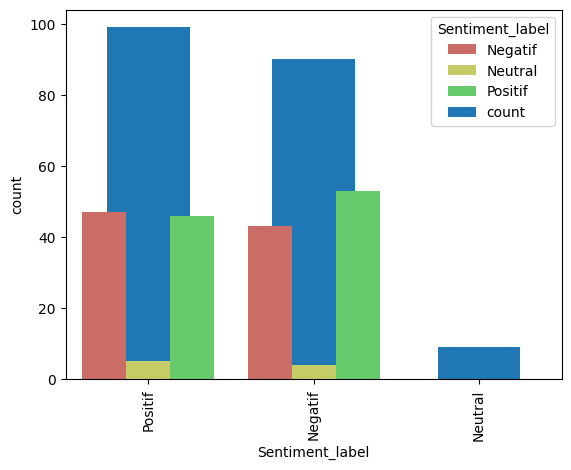

In [8]:
d['Sentiment_label'].value_counts().plot.bar()
import seaborn as sns
sns.countplot(x = 'fake_or_factual', hue = 'Sentiment_label', palette = sns.color_palette("hls"),data = d) 

In [9]:
d.columns.values

array(['title', 'text', 'date', 'fake_or_factual', 'Sentiment_score',
       'Sentiment_label'], dtype=object)

In [27]:
X = [','.join(map(str,l)) for l in d['text']]
Y = d['fake_or_factual']

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [29]:
countvec = CountVectorizer()
countvec_transform = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_transform.toarray(), columns = countvec.get_feature_names_out())

In [31]:
bag_of_words

,01,03,05,08441,10,100,1000,10000,1000000000000000,1002,...,zimbabwean,zimdars,zimmerman,zina,zionism,zoe,zone,zoom,zouka,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
194,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size=0.3)
lr = LogisticRegression(random_state=0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(accuracy_score(y_pred_lr, y_test))
print(classification_report(y_test, y_pred_lr))

0.85
              precision    recall  f1-score   support

Factual News       0.79      0.93      0.86        29
   Fake News       0.92      0.77      0.84        31

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



In [ ]:
svm = SGDClassifier().fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(accuracy_score(y_pred_svm, y_test))
print(classification_report(y_test, y_pred_svm))